**Навигация по уроку**

1. [Библиотеки Python для Data Science]
2. [Отзывы к фильмам (исследуем датасет IMDB)]
3. Домашняя работа

Используя базу данных фильмов из практической части урока, проверьте следующие гипотезы:

1. Большинство фильмов выпускаются по пятницам
2. Известные актеры снимаются в самых кассовых фильмах
3. Известные актеры снимаются в самыx дорогих фильмах

Построить графики по гипотезам. Сколько актеров из вашего результата вам знакомы?

Архив уже существует, пропускаем скачивание.
Папка с данными уже существует.
Чтение movies_metadata.csv...
Чтение credits.csv...
Размер объединённого датафрейма: (45538, 22)


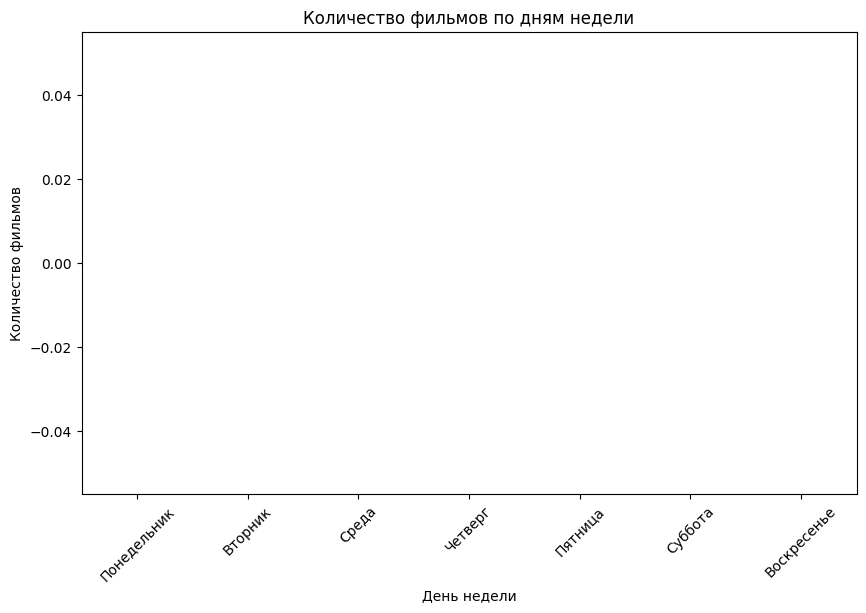

Гипотеза 1: количество фильмов по дням недели
weekday
Понедельник   NaN
Вторник       NaN
Среда         NaN
Четверг       NaN
Пятница       NaN
Суббота       NaN
Воскресенье   NaN
Name: count, dtype: float64

Топ-20 самых кассовых фильмов и их актёры:
Avatar (сборы: $2,787,965,087)
Актёры: Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang, Michelle Rodriguez
--------------------------------------------------
Star Wars: The Force Awakens (сборы: $2,068,223,624)
Актёры: Daisy Ridley, John Boyega, Adam Driver, Harrison Ford, Oscar Isaac
--------------------------------------------------
Titanic (сборы: $1,845,034,188)
Актёры: Kate Winslet, Leonardo DiCaprio, Frances Fisher, Billy Zane, Kathy Bates
--------------------------------------------------
The Avengers (сборы: $1,519,557,910)
Актёры: Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Johansson
--------------------------------------------------
Jurassic World (сборы: $1,513,528,810)
Актёры: Chris Pra

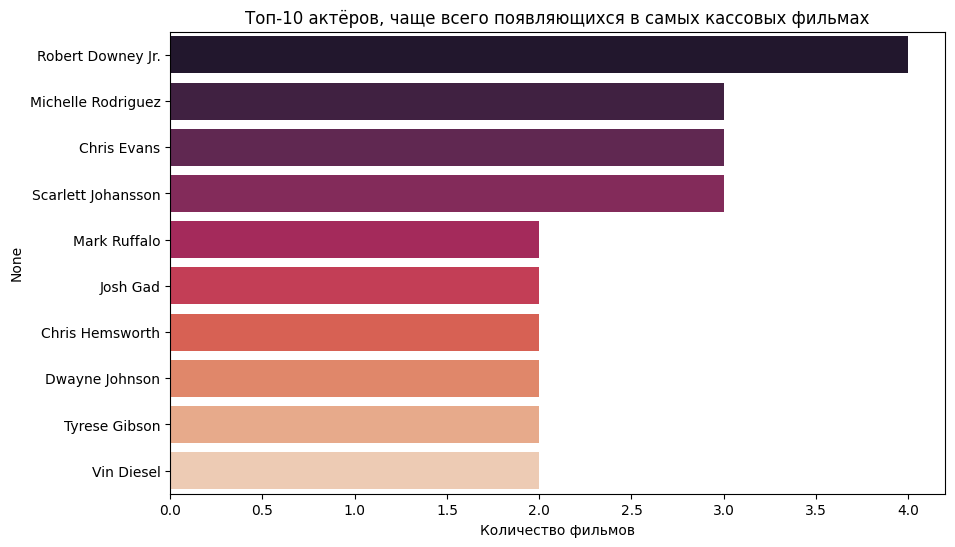


Сколько из этих актёров вам знакомы? (посмотрите на список выше)

Топ-20 самых дорогих фильмов и их актёры:
Pirates of the Caribbean: On Stranger Tides (бюджет: $380,000,000)
Актёры: Johnny Depp, Penélope Cruz, Ian McShane, Kevin McNally, Geoffrey Rush
--------------------------------------------------
Pirates of the Caribbean: At World's End (бюджет: $300,000,000)
Актёры: Johnny Depp, Orlando Bloom, Keira Knightley, Stellan Skarsgård, Chow Yun-fat
--------------------------------------------------
Avengers: Age of Ultron (бюджет: $280,000,000)
Актёры: Robert Downey Jr., Chris Hemsworth, Mark Ruffalo, Chris Evans, Scarlett Johansson
--------------------------------------------------
Superman Returns (бюджет: $270,000,000)
Актёры: Brandon Routh, Kevin Spacey, Kate Bosworth, James Marsden, Parker Posey
--------------------------------------------------
Tangled (бюджет: $260,000,000)
Актёры: Mandy Moore, Zachary Levi, Donna Murphy, Delaney Rose Stein, Brad Garrett
-----------------------

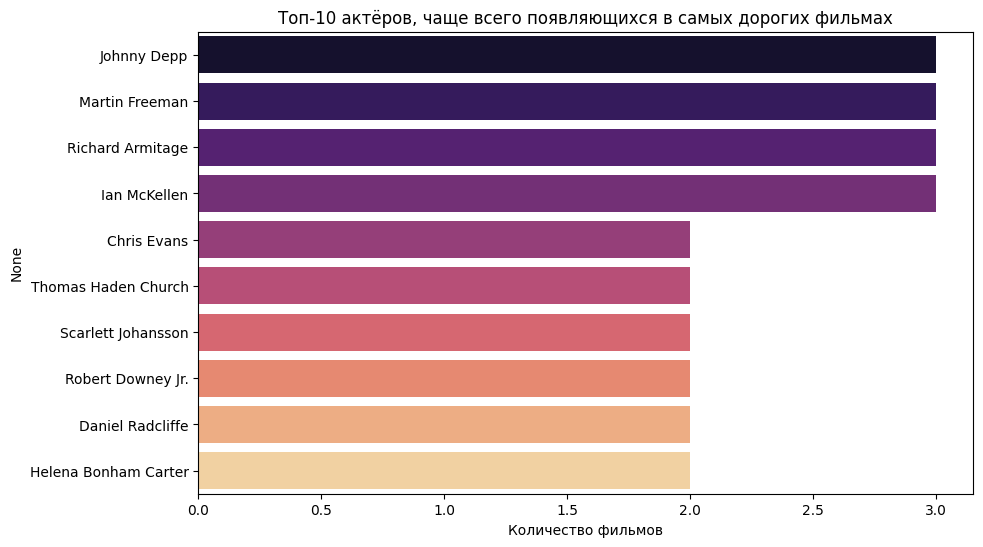


Сколько из этих актёров вам знакомы? (посмотрите на список выше)


In [2]:

# 1. Распаковка датасета

import os
import requests
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Скачиваем архив, если его ещё нет
zip_path = 'the_movies_dataset.zip'
if not os.path.exists(zip_path):
    print("Скачивание датасета...")
    response = requests.get("https://storage.yandexcloud.net/academy.ai/the_movies_dataset.zip", stream=True)
    with open(zip_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Скачивание завершено.")
else:
    print("Архив уже существует, пропускаем скачивание.")

# Распаковываем в папку ./the_movies_dataset (если папка пуста)
extract_path = './the_movies_dataset'
if not os.path.exists(extract_path) or not os.listdir(extract_path):
    print("Распаковка...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Распаковка завершена.")
else:
    print("Папка с данными уже существует.")

FILE_PATH = extract_path

# 2. Импорт библиотек для анализа

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Для отображения графиков в Jupyter (если используется)
%matplotlib inline

# 3. Чтение основных файлов

print("Чтение movies_metadata.csv...")
df = pd.read_csv(os.path.join(FILE_PATH, 'movies_metadata.csv'))

print("Чтение credits.csv...")
credits_df = pd.read_csv(os.path.join(FILE_PATH, 'credits.csv'))

# 4. Предобработка movies_metadata

# Удаление ненужных столбцов
columns_to_drop = ['imdb_id', 'adult', 'belongs_to_collection', 'homepage', 'video', 'poster_path', 'production_companies']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Очистка бюджета
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['budget'] = df['budget'].replace(0, np.nan)

# Очистка сборов
df['revenue'] = df['revenue'].replace(0, np.nan)

# Создание столбца year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Создание столбца return (ROI в процентах)
df['return'] = (df['revenue'] / df['budget']) * 100

# Создание столбца month для гипотезы 1 (не обязательно, но оставим для совместимости)
month_order = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
def get_month(x):
    try:
        return month_order[int(x.strftime('%m')) - 1]
    except:
        return np.nan
df['month'] = df['release_date'].apply(get_month)

# Приведение id к целому типу
def convert_int(x):
    try:
        return int(x)
    except:
        return np.nan

df['id'] = df['id'].apply(convert_int)
df = df.dropna(subset=['id'])
df['id'] = df['id'].astype(int)

# 5. Предобработка credits

# Преобразование строковых представлений списков в реальные списки
credits_df['cast'] = credits_df['cast'].apply(ast.literal_eval)
credits_df['crew'] = credits_df['crew'].apply(ast.literal_eval)

# 6. Объединение датафреймов по id

df_merge = df.merge(credits_df, on='id', how='inner')
print(f"Размер объединённого датафрейма: {df_merge.shape}")

# 7. Извлечение актёров (первые 5 для каждого фильма)

def get_actors(cast_list, top_n=5):
    """Возвращает список имён первых top_n актёров."""
    names = []
    if isinstance(cast_list, list):
        for actor in cast_list[:top_n]:
            if isinstance(actor, dict) and 'name' in actor:
                names.append(actor['name'])
    return names

df_merge['actors'] = df_merge['cast'].apply(lambda x: get_actors(x, top_n=5))

# 8. Проверка гипотезы 1: большинство фильмов выходят по пятницам

# Создаём столбец с днём недели (на английском для универсальности)
df_merge['weekday'] = df_merge['release_date'].dt.day_name()

# Удаляем фильмы без даты
df_weekday = df_merge.dropna(subset=['weekday'])

# Подсчёт количества фильмов по дням недели
weekday_counts = df_weekday['weekday'].value_counts()

# Упорядочим дни
days_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
weekday_counts = weekday_counts.reindex(days_order)

# График
plt.figure(figsize=(10,6))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis')
plt.title('Количество фильмов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.show()

print("Гипотеза 1: количество фильмов по дням недели")
print(weekday_counts)
print()

# 9. Проверка гипотезы 2: известные актёры снимаются в самых кассовых фильмах

# Выбираем топ-20 фильмов по кассовым сборам (revenue)
top_revenue = df_merge.dropna(subset=['revenue']).sort_values('revenue', ascending=False).head(20)

print("Топ-20 самых кассовых фильмов и их актёры:")
for idx, row in top_revenue.iterrows():
    print(f"{row['title']} (сборы: ${row['revenue']:,.0f})")
    print(f"Актёры: {', '.join(row['actors'])}")
    print("-" * 50)

# Подсчёт частоты актёров
all_actors_revenue = []
for actors in top_revenue['actors']:
    all_actors_revenue.extend(actors)

actor_counts_revenue = Counter(all_actors_revenue)
print("\nСамые частые актёры в топ-20 кассовых фильмов:")
for actor, count in actor_counts_revenue.most_common(10):
    print(f"{actor}: {count} фильмов")

# График
top_actors_revenue = pd.Series(actor_counts_revenue).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_actors_revenue.values, y=top_actors_revenue.index, palette='rocket')
plt.title('Топ-10 актёров, чаще всего появляющихся в самых кассовых фильмах')
plt.xlabel('Количество фильмов')
plt.show()

# Вопрос: сколько актёров знакомы? (ответ введите вручную)
print("\nСколько из этих актёров вам знакомы? (посмотрите на список выше)")
print()

# 10. Проверка гипотезы 3: известные актёры снимаются в самых дорогих фильмах

# Топ-20 фильмов по бюджету
top_budget = df_merge.dropna(subset=['budget']).sort_values('budget', ascending=False).head(20)

print("Топ-20 самых дорогих фильмов и их актёры:")
for idx, row in top_budget.iterrows():
    print(f"{row['title']} (бюджет: ${row['budget']:,.0f})")
    print(f"Актёры: {', '.join(row['actors'])}")
    print("-" * 50)

# Подсчёт частоты
all_actors_budget = []
for actors in top_budget['actors']:
    all_actors_budget.extend(actors)

actor_counts_budget = Counter(all_actors_budget)
print("\nСамые частые актёры в топ-20 дорогих фильмов:")
for actor, count in actor_counts_budget.most_common(10):
    print(f"{actor}: {count} фильмов")

# График
top_actors_budget = pd.Series(actor_counts_budget).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_actors_budget.values, y=top_actors_budget.index, palette='magma')
plt.title('Топ-10 актёров, чаще всего появляющихся в самых дорогих фильмах')
plt.xlabel('Количество фильмов')
plt.show()

print("\nСколько из этих актёров вам знакомы? (посмотрите на список выше)")